# Задание 3: Эмпирическое распределение и p-value


генерируем случайные фоновые последовательности и строим эмпирическое распределение скоров

In [9]:
import numpy as np
import math
import matplotlib.pyplot as plt

## PWM из задания 1 

In [10]:
sites = [
    "GAGGTAAAC", "TCCGTAAGC", "CAGGTTGGA",
    "ACAGTCAGC", "TAGGTCAGC", "CAGGTCAGC",
    "CAGGTCGAT", "CAGGTCAGC", "CAGGTCAGC",
    "CAGGTTGGC"
]

nucleotides = ['A', 'C', 'G', 'T']
N = len(sites)
L = len(sites[0])
alpha = 0.1

# PFM
pfm = np.zeros((4, L), dtype=int)
nuc_index = {'A': 0, 'C': 1, 'G': 2, 'T': 3}
for seq in sites:
    for pos in range(L):
        pfm[nuc_index[seq[pos]], pos] += 1

# PPM
ppm = [[0] * L for _ in range(4)]
for pos in range(L):
    count_A = pfm[0][pos] + alpha
    count_C = pfm[1][pos] + alpha
    count_G = pfm[2][pos] + alpha
    count_T = pfm[3][pos] + alpha
    total = count_A + count_C + count_G + count_T
    ppm[0][pos] = count_A / total
    ppm[1][pos] = count_C / total
    ppm[2][pos] = count_G / total
    ppm[3][pos] = count_T / total

# PWM
bg_A = 0.295; bg_C = 0.205; bg_G = 0.205; bg_T = 0.295
pwm = [[0] * L for _ in range(4)]
for pos in range(L):
    pwm[0][pos] = math.log2(ppm[0][pos] / bg_A)
    pwm[1][pos] = math.log2(ppm[1][pos] / bg_C)
    pwm[2][pos] = math.log2(ppm[2][pos] / bg_G)
    pwm[3][pos] = math.log2(ppm[3][pos] / bg_T)


## 1–2. Генератор случайных последовательностей длины L = 9

Частоты нуклеотидов генома человека: A/T = 0.295, G/C = 0.205.

In [11]:
bg = [0.295, 0.205, 0.205, 0.295]  # A, C, G, T
N_BG = 100_000
np.random.seed(42)

# Каждая строка это случайная последовательность в виде индексов нуклеотидов
bg_seqs = np.random.choice(4, size=(N_BG, L), p=bg)

print(f"Сгенерировано {N_BG} случайных последовательностей длиной {L}.")

Сгенерировано 100000 случайных последовательностей длиной 9.


## 3. Скор каждой фоновой последовательности

$$S(x) = \sum_{i=1}^{L} w_{x_i,\, i}$$

In [12]:
pwm_np = np.array(pwm)  # shape (4, L) — для быстрого индексирования

bg_scores = np.zeros(N_BG)
for pos in range(L):
    bg_scores += pwm_np[bg_seqs[:, pos], pos]

print(f"Среднее: {bg_scores.mean():.4f}")
print(f"Стд:     {bg_scores.std():.4f}")
print(f"Мин:     {bg_scores.min():.4f}")
print(f"Макс:    {bg_scores.max():.4f}")

Среднее: -16.5902
Стд:     7.4073
Мин:     -39.9434
Макс:    12.6506


## 4. Гистограмма распределения скоров

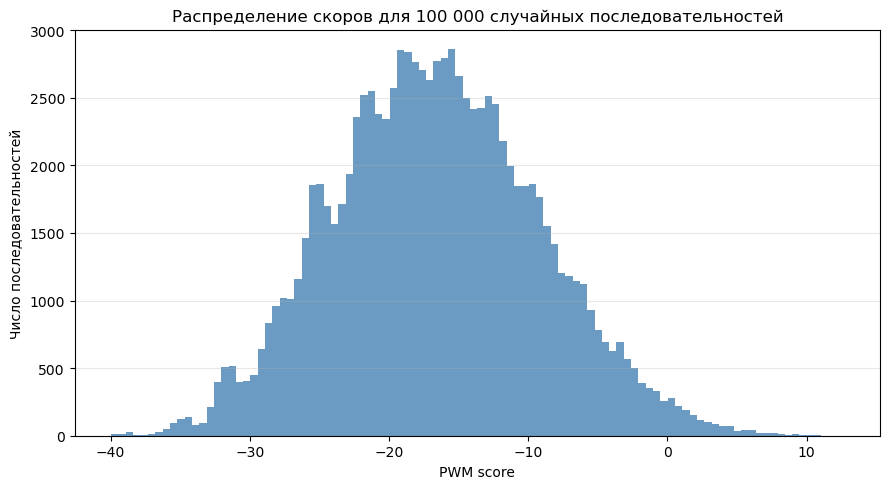

In [13]:
plt.figure(figsize=(9, 5))
plt.hist(bg_scores, bins=100, color='steelblue', edgecolor='none', alpha=0.8)
plt.xlabel("PWM score")
plt.ylabel("Число последовательностей")
plt.title("Распределение скоров для 100 000 случайных последовательностей")
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig("bg_score_distribution.png", dpi=150)
plt.show()

## 5. Функция get_pvalue

$$\text{p-value}(S_0) = P(S \geq S_0 \mid H_0)$$

In [14]:
def get_pvalue(score, bg_scores):
    """Доля фоновых скоров >= score — эмпирический p-value."""
    return np.mean(bg_scores >= score)

for test_score in [0, 2, 4, 6, 8, 10]:
    pval = get_pvalue(test_score, bg_scores)
    print(f"score = {test_score:5.1f}  ->  p-value = {pval:.6f}")

score =   0.0  ->  p-value = 0.015440
score =   2.0  ->  p-value = 0.007220
score =   4.0  ->  p-value = 0.003320
score =   6.0  ->  p-value = 0.001490
score =   8.0  ->  p-value = 0.000520
score =  10.0  ->  p-value = 0.000140


## 6. Порог для p-value ≈ 10⁻⁴

Порог для p-value ≈ 1e-4: 10.4406
Фактический p-value:       0.000100


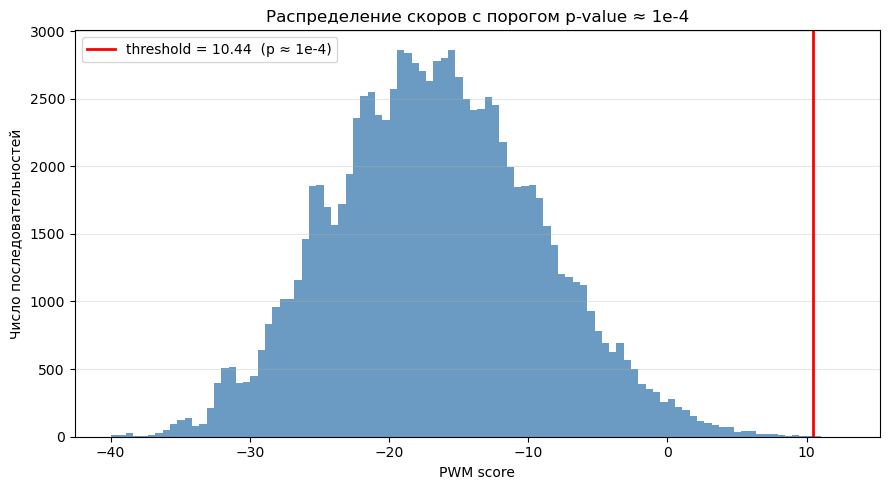

In [15]:
target_pvalue = 1e-4
threshold = np.quantile(bg_scores, 1 - target_pvalue)
actual_pvalue = get_pvalue(threshold, bg_scores)

print(f"Порог для p-value ≈ 1e-4: {threshold:.4f}")
print(f"Фактический p-value:       {actual_pvalue:.6f}")

plt.figure(figsize=(9, 5))
plt.hist(bg_scores, bins=100, color='steelblue', edgecolor='none', alpha=0.8)
plt.axvline(threshold, color='red', linewidth=2, label=f"threshold = {threshold:.2f}  (p ≈ 1e-4)")
plt.xlabel("PWM score")
plt.ylabel("Число последовательностей")
plt.title("Распределение скоров с порогом p-value ≈ 1e-4")
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig("bg_score_threshold.png", dpi=150)
plt.show()